<a href="https://colab.research.google.com/github/Sanika-tech123/Deep-Learning-Lab/blob/main/DL_8_Classifying_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Pretrained Model Loaded Successfully


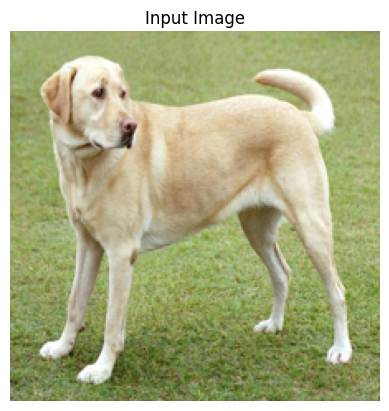

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Top Predictions:

Object Name: Labrador_retriever
Confidence: 25.65 %

Object Name: Saluki
Confidence: 7.17 %

Object Name: Ibizan_hound
Confidence: 4.69 %



In [ ]:
# Import libraries
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import decode_predictions

from tensorflow.keras.preprocessing import image

import numpy as np
import matplotlib.pyplot as plt

import requests
from PIL import Image
from io import BytesIO

# ---------------------------------------------------
# Load Pretrained Model
# ---------------------------------------------------

model = MobileNetV2(weights='imagenet')

print("Pretrained Model Loaded Successfully")

# ---------------------------------------------------
# Load Image from URL
# ---------------------------------------------------

img_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"

response = requests.get(img_url)

img = Image.open(BytesIO(response.content))

# Resize image
img = img.resize((224, 224))

# ---------------------------------------------------
# Display Image
# ---------------------------------------------------

plt.imshow(img)

plt.title("Input Image")

plt.axis('off')

plt.show()

# ---------------------------------------------------
# Convert Image into Array
# ---------------------------------------------------

img_array = image.img_to_array(img)

# Add extra dimension
img_array = np.expand_dims(img_array, axis=0)

# ---------------------------------------------------
# Preprocess Image
# ---------------------------------------------------

img_array = preprocess_input(img_array)

# ---------------------------------------------------
# Make Prediction
# ---------------------------------------------------

predictions = model.predict(img_array)

# Decode Predictions
decoded_predictions = decode_predictions(predictions, top=3)[0]

# ---------------------------------------------------
# Print Predictions
# ---------------------------------------------------

print("\nTop Predictions:\n")

for i in decoded_predictions:

    print("Object Name:", i[1])

    print("Confidence:",
          round(i[2] * 100, 2), "%")

    print()